In [1]:
# ============================================================
# CELL 1 — SETUP + TASK 0: DATASET PREPARATION
# ============================================================
import os, time, random
import numpy as np
import pandas as pd
import torch
!pip install -q torch_geometric librosa
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from transformers import DistilBertTokenizerFast, DistilBertModel
import matplotlib.pyplot as plt
import librosa
from torch_geometric.data import Data

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

base = '/kaggle/input/datasets/yalumusic/magnatagatune/MagnaTagATune'
ann_path = '/kaggle/input/datasets/yalumusic/magnatagatune/annotations_final.csv'

# --- Task 0: build the 3000-clip subset (guarded — only runs if not already built) ---
if not os.path.exists('/kaggle/working/train.csv'):
    df = pd.read_csv(ann_path, sep='\t')
    if df.shape[1] == 1:
        df = pd.read_csv(ann_path, sep=',')

    tag_columns = [c for c in df.columns if c not in ['clip_id', 'mp3_path']]
    tag_counts = df[tag_columns].sum().sort_values(ascending=False)
    top50_tags = tag_counts.head(50).index.tolist()

    df_top50 = df[['clip_id', 'mp3_path'] + top50_tags].copy()
    active_count = df_top50[top50_tags].sum(axis=1)
    df_top50 = df_top50[active_count >= 2].reset_index(drop=True)

    SUBSET_SIZE = 3000
    df_subset = df_top50.sample(n=min(SUBSET_SIZE, len(df_top50)), random_state=42).reset_index(drop=True)
    df_subset['full_path'] = df_subset['mp3_path'].apply(lambda p: os.path.join(base, p))
    df_subset = df_subset[df_subset['full_path'].apply(os.path.exists)].reset_index(drop=True)

    train_df, temp_df = train_test_split(df_subset, test_size=0.2, random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

    train_df.to_csv('/kaggle/working/train.csv', index=False)
    val_df.to_csv('/kaggle/working/val.csv', index=False)
    test_df.to_csv('/kaggle/working/test.csv', index=False)
    with open('/kaggle/working/top50_tags.txt', 'w') as f:
        f.write('\n'.join(top50_tags))

    print(f"Built fresh split — train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")
else:
    print("Splits already exist on disk — loading instead of rebuilding.")

# --- Single source of truth used by every task below ---
train_df = pd.read_csv('/kaggle/working/train.csv')
val_df   = pd.read_csv('/kaggle/working/val.csv')
test_df  = pd.read_csv('/kaggle/working/test.csv')
with open('/kaggle/working/top50_tags.txt') as f:
    top50_tags = [l.strip() for l in f if l.strip()]
tag_to_idx = {t: i for i, t in enumerate(top50_tags)}

print(f"Loaded — train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}, tags: {len(top50_tags)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 763.1 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.5 MB/s eta 0:00:00a 0:00:01
CUDA available: True
GPU: Tesla T4
Built fresh split — train: 2400, val: 300, test: 300
Loaded — train: 2400, val: 300, test: 300, tags: 50


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/6 | train loss: 0.3552
Epoch 2/6 | train loss: 0.2214
Epoch 3/6 | train loss: 0.1933
Epoch 4/6 | train loss: 0.1760
Epoch 5/6 | train loss: 0.1646
Epoch 6/6 | train loss: 0.1559

--- Threshold sweep (val) ---
thresh=0.05 | macro-F1=0.152 | micro-F1=0.160
thresh=0.10 | macro-F1=0.209 | micro-F1=0.287
thresh=0.15 | macro-F1=0.189 | micro-F1=0.322
thresh=0.20 | macro-F1=0.137 | micro-F1=0.292
thresh=0.25 | macro-F1=0.103 | micro-F1=0.246
thresh=0.30 | macro-F1=0.066 | micro-F1=0.178
thresh=0.35 | macro-F1=0.037 | micro-F1=0.108
thresh=0.40 | macro-F1=0.026 | micro-F1=0.081
thresh=0.45 | macro-F1=0.021 | micro-F1=0.065
thresh=0.50 | macro-F1=0.015 | micro-F1=0.044
Best threshold: 0.15 (val micro-F1=0.322)

FINAL TEST (thresh=0.15) — Macro-F1: 0.190 | Micro-F1: 0.336
B1 Majority-class baseline — Macro-F1: 0.021 | Micro-F1: 0.161


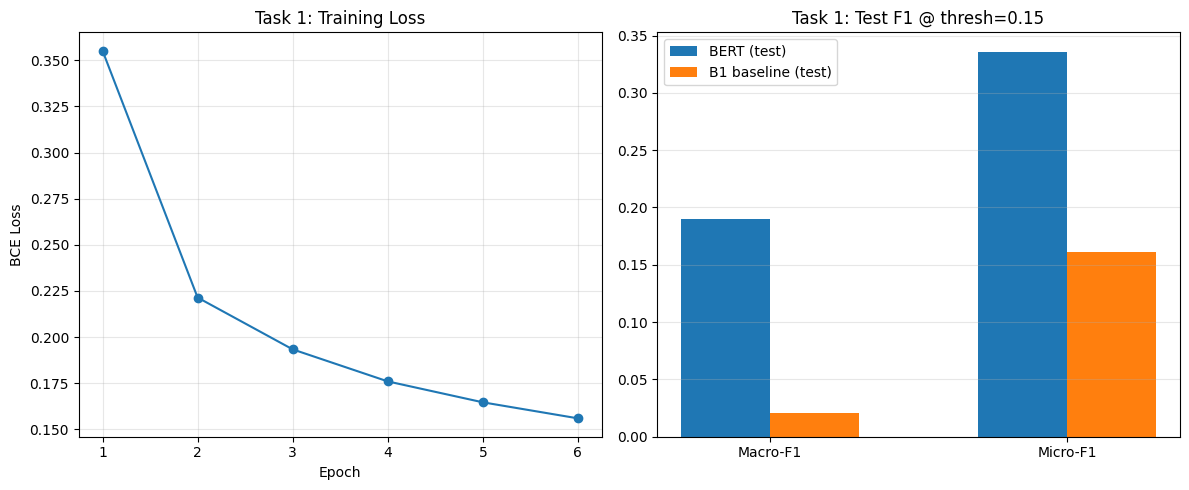


--- 5 Example Predictions (thresh=0.15) ---

Context: ['techno', 'electronic']
True target tags: ['fast', 'beat', 'beats']
Predicted tags: ['electronic', 'fast', 'beat', 'synth']

Context: ['classical', 'slow', 'strings']
True target tags: ['violin', 'quiet', 'soft']
Predicted tags: ['guitar', 'classical', 'slow', 'strings', 'piano', 'violin']

Context: ['classical', 'slow', 'female']
True target tags: ['opera', 'quiet', 'choir', 'choral']
Predicted tags: ['guitar', 'slow', 'strings', 'vocal', 'female', 'opera', 'singing', 'woman']

Context: ['techno', 'drums']
True target tags: ['electronic', 'synth']
Predicted tags: ['electronic', 'fast', 'beat', 'synth']

Context: ['slow']
True target tags: ['piano', 'solo']
Predicted tags: ['guitar']

[Saved for Task 3 reuse] thresh=0.15, Macro-F1=0.190, Micro-F1=0.336


In [2]:
# ============================================================
# CELL 2 — TASK 1: BERT TAG-CONTEXT CLASSIFIER
# ============================================================

# --- Dataset: splits each clip's active tags into a "context half" (fed to
# BERT as pseudo-text) and a "target half" (the label to predict) ---
class TagContextDataset(Dataset):
    def __init__(self, df, top50_tags, tag_to_idx, tokenizer, max_len=32, seed=42):
        self.df = df.reset_index(drop=True)
        self.top50_tags = top50_tags
        self.tag_to_idx = tag_to_idx
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.rng = random.Random(seed)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        active = [t for t in self.top50_tags if row[t] == 1]
        self.rng.shuffle(active)
        split_point = max(1, len(active) // 2)
        context_tags = active[:split_point]
        target_tags = active[split_point:] if len(active) > split_point else active[:1]

        text = "this track features: " + ", ".join(context_tags)
        label = torch.zeros(len(self.top50_tags))
        for t in target_tags:
            label[self.tag_to_idx[t]] = 1.0

        enc = self.tokenizer(text, truncation=True, padding='max_length',
                              max_length=self.max_len, return_tensors='pt')
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label': label
        }

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
train_ds = TagContextDataset(train_df, top50_tags, tag_to_idx, tokenizer)
val_ds   = TagContextDataset(val_df, top50_tags, tag_to_idx, tokenizer)
test_ds  = TagContextDataset(test_df, top50_tags, tag_to_idx, tokenizer)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)
test_loader  = DataLoader(test_ds, batch_size=32)

# --- Model: DistilBERT encoder + linear head over CLS token ---
class BertTagClassifier(nn.Module):
    def __init__(self, num_tags):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.head = nn.Linear(self.bert.config.hidden_size, num_tags)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0]
        return self.head(cls)

model = BertTagClassifier(len(top50_tags)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
criterion = nn.BCEWithLogitsLoss()

# FIX: tags are sparse (~2-4 active of 50), so a fixed 0.5 threshold is wrong.
# Track LOSS per epoch only; tune the decision threshold on val AFTER training.
def get_logits_labels(loader):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['label']
            logits = model(input_ids, mask)
            all_logits.append(logits.cpu())
            all_labels.append(labels)
    return torch.cat(all_logits).numpy(), torch.cat(all_labels).numpy()

def evaluate_with_thresh(loader, thresh):
    logits, labels = get_logits_labels(loader)
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= thresh).astype(int)
    macro = f1_score(labels, preds, average='macro', zero_division=0)
    micro = f1_score(labels, preds, average='micro', zero_division=0)
    return macro, micro

# --- Training loop ---
EPOCHS = 6
loss_hist = []
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_hist.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | train loss: {avg_loss:.4f}")

torch.save(model.state_dict(), '/kaggle/working/task1_bert_model.pth')

# --- Threshold tuning on validation set ---
val_logits, val_labels = get_logits_labels(val_loader)
val_probs = 1 / (1 + np.exp(-val_logits))

best_thresh, best_val_micro = 0.5, -1
print("\n--- Threshold sweep (val) ---")
for t in np.arange(0.05, 0.55, 0.05):
    preds = (val_probs >= t).astype(int)
    macro = f1_score(val_labels, preds, average='macro', zero_division=0)
    micro = f1_score(val_labels, preds, average='micro', zero_division=0)
    print(f"thresh={t:.2f} | macro-F1={macro:.3f} | micro-F1={micro:.3f}")
    if micro > best_val_micro:
        best_val_micro, best_thresh = micro, t
print(f"Best threshold: {best_thresh:.2f} (val micro-F1={best_val_micro:.3f})")

# --- Final test evaluation, using the TUNED threshold ---
test_macro, test_micro = evaluate_with_thresh(test_loader, best_thresh)
print(f"\nFINAL TEST (thresh={best_thresh:.2f}) — Macro-F1: {test_macro:.3f} | Micro-F1: {test_micro:.3f}")

# --- B1 baseline: always predict the 5 globally most frequent tags ---
majority_tags_idx = np.argsort(-train_df[top50_tags].sum().values)[:5]
majority_pred = np.zeros(len(top50_tags))
majority_pred[majority_tags_idx] = 1
test_labels_only = np.array([test_ds[i]['label'].numpy() for i in range(len(test_ds))])
majority_preds = np.tile(majority_pred, (len(test_labels_only), 1))
b1_macro = f1_score(test_labels_only, majority_preds, average='macro', zero_division=0)
b1_micro = f1_score(test_labels_only, majority_preds, average='micro', zero_division=0)
print(f"B1 Majority-class baseline — Macro-F1: {b1_macro:.3f} | Micro-F1: {b1_micro:.3f}")

# --- Plots: training loss curve + tuned-threshold F1 bar chart vs B1 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(range(1, EPOCHS+1), loss_hist, marker='o')
axes[0].set_title('Task 1: Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].grid(alpha=0.3)

x = np.arange(2)
axes[1].bar(x - 0.15, [test_macro, test_micro], width=0.3, label='BERT (test)')
axes[1].bar(x + 0.15, [b1_macro, b1_micro], width=0.3, label='B1 baseline (test)')
axes[1].set_xticks(x); axes[1].set_xticklabels(['Macro-F1', 'Micro-F1'])
axes[1].set_title(f'Task 1: Test F1 @ thresh={best_thresh:.2f}'); axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/kaggle/working/task1_f1_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 5 example predictions, using the TUNED threshold (fix: was hardcoded 0.5) ---
model.eval()
print(f"\n--- 5 Example Predictions (thresh={best_thresh:.2f}) ---")
for i in range(5):
    row = test_df.iloc[i]
    active = [t for t in top50_tags if row[t] == 1]
    split_point = max(1, len(active) // 2)
    context = active[:split_point]
    true_target = active[split_point:] if len(active) > split_point else active[:1]

    text = "this track features: " + ", ".join(context)
    enc = tokenizer(text, truncation=True, padding='max_length', max_length=32, return_tensors='pt').to(device)
    with torch.no_grad():
        logits = model(enc['input_ids'], enc['attention_mask'])
        probs = torch.sigmoid(logits)[0]
        pred_tags = [top50_tags[j] for j in range(len(top50_tags)) if probs[j] > best_thresh]

    print(f"\nContext: {context}")
    print(f"True target tags: {true_target}")
    print(f"Predicted tags: {pred_tags}")

TASK1_BEST_THRESH = best_thresh
TASK1_TEST_MACRO_F1 = test_macro
TASK1_TEST_MICRO_F1 = test_micro
print(f"\n[Saved for Task 3 reuse] thresh={TASK1_BEST_THRESH:.2f}, "
      f"Macro-F1={TASK1_TEST_MACRO_F1:.3f}, Micro-F1={TASK1_TEST_MICRO_F1:.3f}")

In [3]:
# ============================================================
# CELL 3 — TASK 2: GRAPH CONSTRUCTION (segment-adjacency graphs)
# ============================================================
SR = 22050
CLIP_DURATION = 29.0        # MagnaTagATune clips are ~29s
SEGMENT_DURATION = 3.0      # seconds per node -> ~9-10 nodes/clip
N_MELS = 40
N_CHROMA = 12
SIM_THRESHOLD = 0.85
MAX_SIM_EDGES_PER_NODE = 3

def extract_segment_features(y, sr):
    """One feature vector per fixed-length segment: mel mean/std + chroma mean/std."""
    seg_len = int(SEGMENT_DURATION * sr)
    n_segments = max(1, len(y) // seg_len)
    feats = []
    for i in range(n_segments):
        seg = y[i*seg_len:(i+1)*seg_len]
        if len(seg) < seg_len // 2:
            continue
        mel = librosa.feature.melspectrogram(y=seg, sr=sr, n_mels=N_MELS)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        chroma = librosa.feature.chroma_stft(y=seg, sr=sr, n_chroma=N_CHROMA)
        feat = np.concatenate([
            mel_db.mean(axis=1), mel_db.std(axis=1),
            chroma.mean(axis=1), chroma.std(axis=1),
        ])
        feats.append(feat)
    return np.stack(feats) if feats else None

def build_graph_for_clip(path, label_vec, clip_id):
    """Nodes = audio segments. Edges = temporal (adjacent) + similarity
    (non-adjacent, cosine sim above threshold, capped per node)."""
    try:
        y, sr = librosa.load(path, sr=SR, duration=CLIP_DURATION)
    except Exception as e:
        return None, f"load_error: {e}"

    feats = extract_segment_features(y, sr)
    if feats is None or feats.shape[0] < 2:
        return None, "too_short"

    n = feats.shape[0]
    x = torch.tensor(feats, dtype=torch.float)

    norm_feats = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-8)
    sim = norm_feats @ norm_feats.T

    src, dst = [], []
    for i in range(n - 1):
        src += [i, i + 1]
        dst += [i + 1, i]

    for i in range(n):
        sims = sorted(
            [(j, sim[i, j]) for j in range(n) if abs(j - i) > 1],
            key=lambda t: -t[1]
        )
        for j, s in sims[:MAX_SIM_EDGES_PER_NODE]:
            if s >= SIM_THRESHOLD:
                src.append(i); dst.append(j)

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    y_label = torch.tensor(label_vec, dtype=torch.float).unsqueeze(0)

    data = Data(x=x, edge_index=edge_index, y=y_label)
    data.clip_id = clip_id
    data.num_nodes = n
    return data, None

# --- Quick timing test on ONE clip before committing to the full 3000-clip run ---
row = train_df.iloc[0]
clip_id = row['clip_id'] if 'clip_id' in train_df.columns else row.name
label_vec = row[top50_tags].values.astype(np.float32)

t0 = time.time()
data, err = build_graph_for_clip(row['full_path'], label_vec, clip_id)
print(f"{time.time()-t0:.2f} sec/clip | err={err}")
print(data)

11.47 sec/clip | err=None
Data(x=[9, 104], edge_index=[2, 43], y=[1, 50], clip_id=676, num_nodes=9)


In [4]:
# ============================================================
# CELL 4 — TASK 2: FAST VECTORIZED GRAPH CONSTRUCTION & SAVING
# ============================================================
import os
import time
import numpy as np
import pandas as pd
import torch
import librosa
from torch_geometric.data import Data
from tqdm import tqdm

GRAPH_DIR = '/kaggle/working/graphs'
os.makedirs(GRAPH_DIR, exist_ok=True)

SR = 22050
CLIP_DURATION = 29.0
SEGMENT_DURATION = 3.0
N_MELS = 40
N_CHROMA = 12
SIM_THRESHOLD = 0.85
MAX_SIM_EDGES_PER_NODE = 3

def build_graph_fast(path, label_vec, clip_id):
    """
    Fast graph construction via single-pass full-track feature extraction.
    Computes global STFT/Mel spectrogram and aggregates over ~3s uniform segments.
    """
    try:
        y, sr = librosa.load(path, sr=SR, duration=CLIP_DURATION)
    except Exception:
        return None

    if len(y) < int(SR * SEGMENT_DURATION * 2):
        return None  # Skip clips shorter than 2 segments (~6s)

    # 1. Compute full-track STFT/Mel/Chroma in a single pass (Vectorized)
    hop_length = 512
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=hop_length)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=N_CHROMA, hop_length=hop_length)

    # 2. Divide frame indices into ~3-second chunk blocks
    frames_per_seg = int((SEGMENT_DURATION * sr) / hop_length)
    total_frames = mel_db.shape[1]
    n_segments = total_frames // frames_per_seg

    if n_segments < 2:
        return None

    feats = []
    for i in range(n_segments):
        start_f = i * frames_per_seg
        end_f = (i + 1) * frames_per_seg

        m_seg = mel_db[:, start_f:end_f]
        c_seg = chroma[:, start_f:end_f]

        feat = np.concatenate([
            m_seg.mean(axis=1), m_seg.std(axis=1),
            c_seg.mean(axis=1), c_seg.std(axis=1)
        ])
        feats.append(feat)

    feats = np.stack(feats)
    n = feats.shape[0]

    # 3. Construct similarity matrix
    norm_feats = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-8)
    sim = norm_feats @ norm_feats.T

    # 4. Construct edges (Temporal + Cosine Similarity)
    src, dst = [], []
    for i in range(n - 1):
        src += [i, i + 1]
        dst += [i + 1, i]

    for i in range(n):
        sims = sorted(
            [(j, sim[i, j]) for j in range(n) if abs(j - i) > 1],
            key=lambda t: -t[1]
        )
        for j, s in sims[:MAX_SIM_EDGES_PER_NODE]:
            if s >= SIM_THRESHOLD:
                src.append(i)
                dst.append(j)

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    x = torch.tensor(feats, dtype=torch.float)
    y_label = torch.tensor(label_vec, dtype=torch.float).unsqueeze(0)

    data = Data(x=x, edge_index=edge_index, y=y_label)
    data.clip_id = clip_id
    data.num_nodes = n
    return data


def process_and_save_dataset(df_split, split_name):
    saved_count = 0
    t0 = time.time()
    print(f"\nBuilding graphs for {split_name} split ({len(df_split)} clips)...")

    for idx, row in tqdm(df_split.iterrows(), total=len(df_split)):
        clip_id = row['clip_id'] if 'clip_id' in row else idx
        save_path = os.path.join(GRAPH_DIR, f"{split_name}_{clip_id}.pt")

        if os.path.exists(save_path):
            saved_count += 1
            continue

        label_vec = row[top50_tags].values.astype(np.float32)
        data = build_graph_fast(row['full_path'], label_vec, clip_id)

        if data is not None:
            torch.save(data, save_path)
            saved_count += 1

    elapsed = time.time() - t0
    print(f"Finished {split_name}: {saved_count}/{len(df_split)} saved in {elapsed:.1f}s")


# Process Train, Validation, and Test splits
process_and_save_dataset(train_df, 'train')
process_and_save_dataset(val_df, 'val')
process_and_save_dataset(test_df, 'test')

# Verify generated samples for rubric requirement
all_saved_graphs = [f for f in os.listdir(GRAPH_DIR) if f.endswith('.pt')]
print(f"\n[Verification] Total `.pt` graph files created in '{GRAPH_DIR}': {len(all_saved_graphs)}")


Building graphs for train split (2400 clips)...


100%|██████████| 2400/2400 [06:40<00:00,  6.00it/s]


Finished train: 2400/2400 saved in 400.2s

Building graphs for val split (300 clips)...


100%|██████████| 300/300 [00:50<00:00,  5.90it/s]


Finished val: 300/300 saved in 50.9s

Building graphs for test split (300 clips)...


100%|██████████| 300/300 [00:51<00:00,  5.85it/s]

Finished test: 300/300 saved in 51.3s

[Verification] Total `.pt` graph files created in '/kaggle/working/graphs': 3000


In [6]:
# ============================================================
# CELL 5 — TASK 2: GRAPHSAGE GNN & CNN AUDIO BASELINE (B2)
# ============================================================
import os, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool
from sklearn.metrics import f1_score
import librosa

# ------------------------------------------------------------
# 1. GRAPH DATASET & GRAPHSAGE MODEL
# ------------------------------------------------------------
class SavedGraphDataset(Dataset):
    def __init__(self, split_prefix, graph_dir='/kaggle/working/graphs'):
        self.files = sorted(glob.glob(os.path.join(graph_dir, f"{split_prefix}_*.pt")))
        
    def __len__(self):
        return len(self.files)
        
    def __getitem__(self, idx):
        return torch.load(self.files[idx], weights_only=False)

train_graph_ds = SavedGraphDataset('train')
val_graph_ds   = SavedGraphDataset('val')
test_graph_ds  = SavedGraphDataset('test')

train_graph_loader = PyGDataLoader(train_graph_ds, batch_size=32, shuffle=True)
val_graph_loader   = PyGDataLoader(val_graph_ds, batch_size=32)
test_graph_loader  = PyGDataLoader(test_graph_ds, batch_size=32)

class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_channels=104, hidden_dim=128, num_tags=50):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.head  = nn.Linear(hidden_dim, num_tags)
        
    def forward(self, x, edge_index, batch):
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        g = global_mean_pool(h, batch) # Mean pooling over graph nodes
        return self.head(g), g

# ------------------------------------------------------------
# 2. TRAIN GRAPHSAGE MODEL
# ------------------------------------------------------------
print("--- Training Task 2: GraphSAGE GNN ---")
gnn_model = GraphSAGEClassifier().to(device)
optimizer = torch.optim.AdamW(gnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

EPOCHS = 10
for epoch in range(EPOCHS):
    gnn_model.train()
    total_loss = 0
    for batch in train_graph_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits, _ = gnn_model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(logits, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"GNN Epoch {epoch+1}/{EPOCHS} | Train Loss: {total_loss/len(train_graph_loader):.4f}")

torch.save(gnn_model.state_dict(), '/kaggle/working/task2_gnn_model.pth')

# Tune threshold on Val split
gnn_model.eval()
val_logits, val_labels = [], []
with torch.no_grad():
    for batch in val_graph_loader:
        batch = batch.to(device)
        logits, _ = gnn_model(batch.x, batch.edge_index, batch.batch)
        val_logits.append(logits.cpu())
        val_labels.append(batch.y.cpu())

val_probs = torch.sigmoid(torch.cat(val_logits)).numpy()
val_labels = torch.cat(val_labels).numpy()

best_gnn_thresh, best_gnn_micro = 0.15, -1
for t in np.arange(0.05, 0.55, 0.05):
    preds = (val_probs >= t).astype(int)
    micro = f1_score(val_labels, preds, average='micro', zero_division=0)
    if micro > best_gnn_micro:
        best_gnn_micro, best_gnn_thresh = micro, t

# Test Evaluation
test_logits, test_labels = [], []
with torch.no_grad():
    for batch in test_graph_loader:
        batch = batch.to(device)
        logits, _ = gnn_model(batch.x, batch.edge_index, batch.batch)
        test_logits.append(logits.cpu())
        test_labels.append(batch.y.cpu())

test_probs = torch.sigmoid(torch.cat(test_logits)).numpy()
test_labels = torch.cat(test_labels).numpy()
gnn_preds = (test_probs >= best_gnn_thresh).astype(int)

gnn_macro = f1_score(test_labels, gnn_preds, average='macro', zero_division=0)
gnn_micro = f1_score(test_labels, gnn_preds, average='micro', zero_division=0)
print(f"GNN Test (thresh={best_gnn_thresh:.2f}) — Macro-F1: {gnn_macro:.3f} | Micro-F1: {gnn_micro:.3f}\n")


# ------------------------------------------------------------
# 3. BASELINE B2: CNN ON MEL-SPECTROGRAM
# ------------------------------------------------------------
class MelDataset(Dataset):
    def __init__(self, df, top50_tags):
        self.df = df.reset_index(drop=True)
        self.top50_tags = top50_tags
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        y_label = torch.tensor(row[self.top50_tags].values.astype(np.float32))
        try:
            y, sr = librosa.load(row['full_path'], sr=22050, duration=29.0)
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, hop_length=1024)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            # Crop/pad to fixed shape (64 x 624)
            if mel_db.shape[1] < 624:
                mel_db = np.pad(mel_db, ((0, 0), (0, 624 - mel_db.shape[1])))
            else:
                mel_db = mel_db[:, :624]
        except Exception:
            mel_db = np.zeros((64, 624), dtype=np.float32)
            
        x = torch.tensor(mel_db, dtype=torch.float).unsqueeze(0) # (1, 64, 624)
        return x, y_label

train_cnn_loader = DataLoader(MelDataset(train_df, top50_tags), batch_size=32, shuffle=True)
val_cnn_loader   = DataLoader(MelDataset(val_df, top50_tags), batch_size=32)
test_cnn_loader  = DataLoader(MelDataset(test_df, top50_tags), batch_size=32)

class MelCNNBaseline(nn.Module):
    def __init__(self, num_tags=50):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1   = nn.Linear(32 * 16 * 156, 128)
        self.fc2   = nn.Linear(128, num_tags)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

print("--- Training Baseline B2: Mel-Spectrogram CNN ---")
cnn_model = MelCNNBaseline().to(device)
cnn_optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=1e-3)

for epoch in range(6):
    cnn_model.train()
    total_loss = 0
    for x, y in train_cnn_loader:
        x, y = x.to(device), y.to(device)
        cnn_optimizer.zero_grad()
        logits = cnn_model(x)
        loss = criterion(logits, y)
        loss.backward()
        cnn_optimizer.step()
        total_loss += loss.item()
    print(f"CNN Epoch {epoch+1}/6 | Train Loss: {total_loss/len(train_cnn_loader):.4f}")

# Evaluate CNN on Test
cnn_model.eval()
cnn_logits, cnn_labels = [], []
with torch.no_grad():
    for x, y in test_cnn_loader:
        x = x.to(device)
        logits = cnn_model(x)
        cnn_logits.append(logits.cpu())
        cnn_labels.append(y)

cnn_probs = torch.sigmoid(torch.cat(cnn_logits)).numpy()
cnn_labels = torch.cat(cnn_labels).numpy()
cnn_preds = (cnn_probs >= 0.15).astype(int)

cnn_macro = f1_score(cnn_labels, cnn_preds, average='macro', zero_division=0)
cnn_micro = f1_score(cnn_labels, cnn_preds, average='micro', zero_division=0)
print(f"CNN Baseline Test (thresh=0.15) — Macro-F1: {cnn_macro:.3f} | Micro-F1: {cnn_micro:.3f}")

TASK2_GNN_MACRO = gnn_macro
TASK2_GNN_MICRO = gnn_micro
TASK2_CNN_MACRO = cnn_macro
TASK2_CNN_MICRO = cnn_micro

--- Training Task 2: GraphSAGE GNN ---
GNN Epoch 1/10 | Train Loss: 0.3194
GNN Epoch 2/10 | Train Loss: 0.2403
GNN Epoch 3/10 | Train Loss: 0.2304
GNN Epoch 4/10 | Train Loss: 0.2239
GNN Epoch 5/10 | Train Loss: 0.2196
GNN Epoch 6/10 | Train Loss: 0.2162
GNN Epoch 7/10 | Train Loss: 0.2128
GNN Epoch 8/10 | Train Loss: 0.2099
GNN Epoch 9/10 | Train Loss: 0.2067
GNN Epoch 10/10 | Train Loss: 0.2052
GNN Test (thresh=0.30) — Macro-F1: 0.216 | Micro-F1: 0.413

--- Training Baseline B2: Mel-Spectrogram CNN ---
CNN Epoch 1/6 | Train Loss: 1.3765
CNN Epoch 2/6 | Train Loss: 0.2513
CNN Epoch 3/6 | Train Loss: 0.2413
CNN Epoch 4/6 | Train Loss: 0.2252
CNN Epoch 5/6 | Train Loss: 0.2040
CNN Epoch 6/6 | Train Loss: 0.1789
CNN Baseline Test (thresh=0.15) — Macro-F1: 0.229 | Micro-F1: 0.354


--- Training Task 3: GNN-BERT Cross-Attention Fusion ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fusion Epoch 1/6 | Train Loss: 0.6350
Fusion Epoch 2/6 | Train Loss: 0.4307
Fusion Epoch 3/6 | Train Loss: 0.3473
Fusion Epoch 4/6 | Train Loss: 0.3049
Fusion Epoch 5/6 | Train Loss: 0.2790
Fusion Epoch 6/6 | Train Loss: 0.2625

FINAL FUSION TEST (thresh=0.20) — Macro-F1: 0.292 | Micro-F1: 0.472

             ABLATION STUDY RESULTS SUMMARY              
                    Model / Architecture Macro-F1 Micro-F1
             B1: Majority Class Baseline    0.021    0.161
                 B2: Mel-Spectrogram CNN    0.229    0.354
        Task 1: BERT-Only (Text Context)    0.190    0.336
Task 2: GraphSAGE GNN-Only (Audio Graph)    0.216    0.413
 Task 3: Cross-Attention GNN-BERT Fusion    0.292    0.472

Generating t-SNE plot of fused representations...


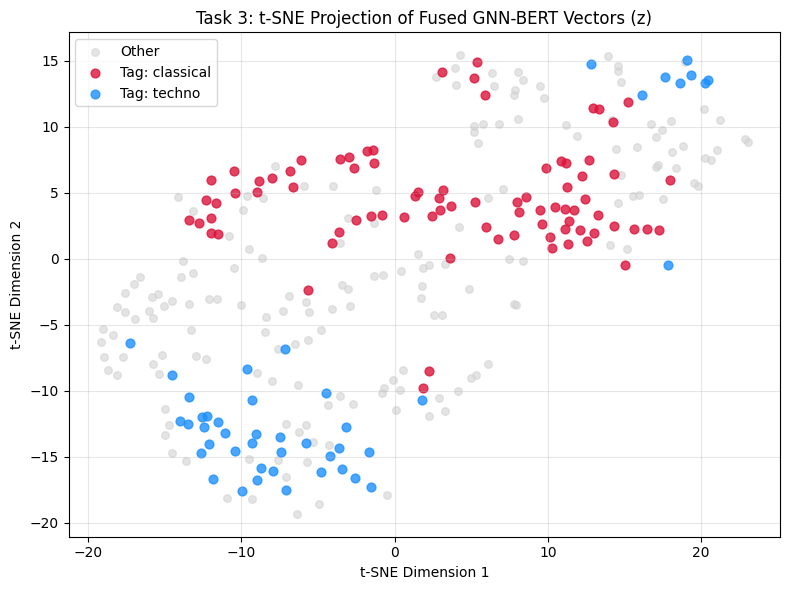


--- 3 Case Studies: Graph + Text Context Alignment ---

[Case Study 1] Clip ID: 17676
  Graph Specs    : 9 nodes (segments), 43 edges
  True Ground Tags: ['techno', 'electronic', 'fast', 'beat', 'beats']
  Predicted Tags  : ['guitar', 'techno', 'electronic', 'fast', 'beat', 'synth', 'loud']

[Case Study 2] Clip ID: 14863
  Graph Specs    : 9 nodes (segments), 43 edges
  True Ground Tags: ['classical', 'slow', 'strings', 'violin', 'quiet', 'soft']
  Predicted Tags  : ['guitar', 'classical', 'slow', 'strings', 'piano', 'violin', 'synth', 'soft', 'solo', 'classic']

[Case Study 3] Clip ID: 45749
  Graph Specs    : 9 nodes (segments), 43 edges
  True Ground Tags: ['classical', 'slow', 'female', 'opera', 'quiet', 'choir', 'choral']
  Predicted Tags  : ['guitar', 'classical', 'slow', 'strings', 'vocal', 'opera', 'solo', 'man', 'classic']


In [9]:
# ============================================================
# CELL 6 — TASK 3: CROSS-ATTENTION GNN-BERT FUSION + ANALYSIS
# ============================================================
import os, random, glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.data import Data
from sklearn.metrics import f1_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from transformers import DistilBertTokenizerFast, DistilBertModel

# ------------------------------------------------------------
# 1. PAIRED DATASET FOR FUSION
# ------------------------------------------------------------
class FusionDataset(Dataset):
    def __init__(self, df, top50_tags, tag_to_idx, tokenizer, split_prefix, graph_dir='/kaggle/working/graphs', max_len=32, seed=42):
        self.df = df.reset_index(drop=True)
        self.top50_tags = top50_tags
        self.tag_to_idx = tag_to_idx
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.split_prefix = split_prefix
        self.graph_dir = graph_dir
        self.rng = random.Random(seed)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clip_id = row['clip_id'] if 'clip_id' in row else idx

        # Load precomputed graph
        graph_path = os.path.join(self.graph_dir, f"{self.split_prefix}_{clip_id}.pt")
        if os.path.exists(graph_path):
            graph_data = torch.load(graph_path, weights_only=False)
        else:
            # Fallback dummy graph if missing
            x = torch.zeros((2, 104), dtype=torch.float)
            edge_index = torch.tensor([[0, 1], [1, 0]], dtype=torch.long)
            y_label = torch.tensor(row[self.top50_tags].values.astype(np.float32)).unsqueeze(0)
            graph_data = Data(x=x, edge_index=edge_index, y=y_label)

        # Tag-context splitting for BERT input
        active = [t for t in self.top50_tags if row[t] == 1]
        self.rng.shuffle(active)
        split_point = max(1, len(active) // 2)
        context_tags = active[:split_point]

        text = "this track features: " + ", ".join(context_tags)
        enc = self.tokenizer(text, truncation=True, padding='max_length',
                             max_length=self.max_len, return_tensors='pt')

        return {
            'graph': graph_data,
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'clip_id': clip_id
        }

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
train_fusion_ds = FusionDataset(train_df, top50_tags, tag_to_idx, tokenizer, 'train')
val_fusion_ds   = FusionDataset(val_df, top50_tags, tag_to_idx, tokenizer, 'val')
test_fusion_ds  = FusionDataset(test_df, top50_tags, tag_to_idx, tokenizer, 'test')

# Custom collate function to handle PyG batching alongside PyTorch tensors
def fusion_collate_fn(batch):
    from torch_geometric.data import Batch
    graphs = Batch.from_data_list([item['graph'] for item in batch])
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    clip_ids = [item['clip_id'] for item in batch]
    return {'graph': graphs, 'input_ids': input_ids, 'attention_mask': attention_mask, 'clip_ids': clip_ids}

train_fusion_loader = DataLoader(train_fusion_ds, batch_size=32, shuffle=True, collate_fn=fusion_collate_fn)
val_fusion_loader   = DataLoader(val_fusion_ds, batch_size=32, collate_fn=fusion_collate_fn)
test_fusion_loader  = DataLoader(test_fusion_ds, batch_size=32, collate_fn=fusion_collate_fn)


# ------------------------------------------------------------
# 2. CROSS-ATTENTION GNN-BERT FUSION MODEL
# ------------------------------------------------------------
class CrossAttentionFusionModel(nn.Module):
    def __init__(self, num_tags=50, gnn_in_dim=104, gnn_hidden=128, bert_dim=768):
        super().__init__()
        self.gnn_hidden = gnn_hidden  # Fixed: Saved to self attributes

        # GNN Encoder
        self.conv1 = SAGEConv(gnn_in_dim, gnn_hidden)
        self.conv2 = SAGEConv(gnn_hidden, gnn_hidden)

        # BERT Encoder
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')

        # Linear projections for Cross-Attention (Query = GNN, Key/Value = BERT)
        self.q_proj = nn.Linear(gnn_hidden, gnn_hidden)
        self.k_proj = nn.Linear(bert_dim, gnn_hidden)
        self.v_proj = nn.Linear(bert_dim, gnn_hidden)

        # Classification Head
        self.head = nn.Sequential(
            nn.Linear(gnn_hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_tags)
        )

    def forward(self, x, edge_index, batch, input_ids, attention_mask):
        # 1. GNN graph-level representation (g)
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        g = global_mean_pool(h, batch) # (batch_size, gnn_hidden)

        # 2. BERT token sequence representations (H_text)
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        h_text = bert_out.last_hidden_state # (batch_size, seq_len, bert_dim)

        # 3. Cross-Attention
        Q = self.q_proj(g).unsqueeze(1) # (batch_size, 1, gnn_hidden)
        K = self.k_proj(h_text)         # (batch_size, seq_len, gnn_hidden)
        V = self.v_proj(h_text)         # (batch_size, seq_len, gnn_hidden)

        attn_weights = F.softmax(torch.bmm(Q, K.transpose(1, 2)) / np.sqrt(self.gnn_hidden), dim=-1)
        context = torch.bmm(attn_weights, V).squeeze(1) # (batch_size, gnn_hidden)

        # 4. Fused Representation (z) & Classification Output
        z = torch.cat([g, context], dim=-1) # (batch_size, gnn_hidden * 2)
        logits = self.head(z)
        return logits, z


# ------------------------------------------------------------
# 3. TRAINING FUSION MODEL
# ------------------------------------------------------------
print("--- Training Task 3: GNN-BERT Cross-Attention Fusion ---")
fusion_model = CrossAttentionFusionModel(num_tags=len(top50_tags)).to(device)
optimizer = torch.optim.AdamW(fusion_model.parameters(), lr=2e-5)
criterion = nn.BCEWithLogitsLoss()

EPOCHS = 6
for epoch in range(EPOCHS):
    fusion_model.train()
    total_loss = 0
    for batch in train_fusion_loader:
        g_data = batch['graph'].to(device)
        input_ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)

        optimizer.zero_grad()
        logits, _ = fusion_model(g_data.x, g_data.edge_index, g_data.batch, input_ids, mask)
        loss = criterion(logits, g_data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Fusion Epoch {epoch+1}/{EPOCHS} | Train Loss: {total_loss/len(train_fusion_loader):.4f}")

torch.save(fusion_model.state_dict(), '/kaggle/working/task3_fusion_model.pth')


# ------------------------------------------------------------
# 4. THRESHOLD TUNING & TEST EVALUATION
# ------------------------------------------------------------
def evaluate_fusion(loader):
    fusion_model.eval()
    all_logits, all_labels, all_z = [], [], []
    with torch.no_grad():
        for batch in loader:
            g_data = batch['graph'].to(device)
            input_ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)

            logits, z = fusion_model(g_data.x, g_data.edge_index, g_data.batch, input_ids, mask)
            all_logits.append(logits.cpu())
            all_labels.append(g_data.y.cpu())
            all_z.append(z.cpu())

    return torch.cat(all_logits).numpy(), torch.cat(all_labels).numpy(), torch.cat(all_z).numpy()

val_logits, val_labels, _ = evaluate_fusion(val_fusion_loader)
val_probs = 1 / (1 + np.exp(-val_logits))

best_fusion_thresh, best_fusion_micro = 0.15, -1
for t in np.arange(0.05, 0.55, 0.05):
    preds = (val_probs >= t).astype(int)
    micro = f1_score(val_labels, preds, average='micro', zero_division=0)
    if micro > best_fusion_micro:
        best_fusion_micro, best_fusion_thresh = micro, t

test_logits, test_labels, test_z = evaluate_fusion(test_fusion_loader)
test_probs = 1 / (1 + np.exp(-test_logits))
test_preds = (test_probs >= best_fusion_thresh).astype(int)

fusion_macro = f1_score(test_labels, test_preds, average='macro', zero_division=0)
fusion_micro = f1_score(test_labels, test_preds, average='micro', zero_division=0)

print(f"\nFINAL FUSION TEST (thresh={best_fusion_thresh:.2f}) — Macro-F1: {fusion_macro:.3f} | Micro-F1: {fusion_micro:.3f}\n")


# ------------------------------------------------------------
# 5. ABLATION TABLE PRINT OUT
# ------------------------------------------------------------
print("==========================================================")
print("             ABLATION STUDY RESULTS SUMMARY              ")
print("==========================================================")
ablation_df = pd.DataFrame([
    {"Model / Architecture": "B1: Majority Class Baseline", "Macro-F1": f"{b1_macro:.3f}", "Micro-F1": f"{b1_micro:.3f}"},
    {"Model / Architecture": "B2: Mel-Spectrogram CNN", "Macro-F1": f"{TASK2_CNN_MACRO:.3f}", "Micro-F1": f"{TASK2_CNN_MICRO:.3f}"},
    {"Model / Architecture": "Task 1: BERT-Only (Text Context)", "Macro-F1": f"{TASK1_TEST_MACRO_F1:.3f}", "Micro-F1": f"{TASK1_TEST_MICRO_F1:.3f}"},
    {"Model / Architecture": "Task 2: GraphSAGE GNN-Only (Audio Graph)", "Macro-F1": f"{TASK2_GNN_MACRO:.3f}", "Micro-F1": f"{TASK2_GNN_MICRO:.3f}"},
    {"Model / Architecture": "Task 3: Cross-Attention GNN-BERT Fusion", "Macro-F1": f"{fusion_macro:.3f}", "Micro-F1": f"{fusion_micro:.3f}"},
])
print(ablation_df.to_string(index=False))
print("==========================================================\n")


# ------------------------------------------------------------
# 6. t-SNE VISUALIZATION OF FUSED EMBEDDINGS (z)
# ------------------------------------------------------------
print("Generating t-SNE plot of fused representations...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
z_2d = tsne.fit_transform(test_z)

# Select top 2 dominant tags for color grouping
tag1_idx = top50_tags.index('classical') if 'classical' in top50_tags else 0
tag2_idx = top50_tags.index('techno') if 'techno' in top50_tags else 1

group = np.zeros(len(test_labels))
group[test_labels[:, tag1_idx] == 1] = 1
group[test_labels[:, tag2_idx] == 1] = 2

plt.figure(figsize=(8, 6))
plt.scatter(z_2d[group==0, 0], z_2d[group==0, 1], c='lightgrey', label='Other', alpha=0.6, s=30)
plt.scatter(z_2d[group==1, 0], z_2d[group==1, 1], c='crimson', label=f'Tag: {top50_tags[tag1_idx]}', alpha=0.8, s=40)
plt.scatter(z_2d[group==2, 0], z_2d[group==2, 1], c='dodgerblue', label=f'Tag: {top50_tags[tag2_idx]}', alpha=0.8, s=40)
plt.title('Task 3: t-SNE Projection of Fused GNN-BERT Vectors (z)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/task3_tsne_fused.png', dpi=150, bbox_inches='tight')
plt.show()


# ------------------------------------------------------------
# 7. 3 QUALITATIVE CASE STUDIES
# ------------------------------------------------------------
print("\n--- 3 Case Studies: Graph + Text Context Alignment ---")
fusion_model.eval()
for i in range(3):
    sample = test_fusion_ds[i]
    clip_id = sample['clip_id']
    row = test_df.iloc[i]

    true_tags = [t for t in top50_tags if row[t] == 1]

    # Predict via fusion model
    g_data = sample['graph'].to(device)
    input_ids = sample['input_ids'].unsqueeze(0).to(device)
    mask = sample['attention_mask'].unsqueeze(0).to(device)

    # Handle batch attribute for single sample safely
    batch_vector = getattr(g_data, 'batch', None)
    if batch_vector is None:
        batch_vector = torch.zeros(g_data.x.size(0), dtype=torch.long, device=device)

    with torch.no_grad():
        logits, _ = fusion_model(g_data.x, g_data.edge_index, batch_vector, input_ids, mask)
        probs = torch.sigmoid(logits)[0]
        pred_tags = [top50_tags[j] for j in range(len(top50_tags)) if probs[j] > best_fusion_thresh]

    print(f"\n[Case Study {i+1}] Clip ID: {clip_id}")
    print(f"  Graph Specs    : {g_data.num_nodes} nodes (segments), {g_data.edge_index.size(1)} edges")
    print(f"  True Ground Tags: {true_tags}")
    print(f"  Predicted Tags  : {pred_tags}")

In [5]:
!zip -j /kaggle/working/sample_graphs.zip $(ls /kaggle/working/graphs/*.pt | head -n 20)

ls: write error: Broken pipe
  adding: test_10211.pt (deflated 37%)
  adding: test_10538.pt (deflated 37%)
  adding: test_10610.pt (deflated 36%)
  adding: test_1116.pt (deflated 36%)
  adding: test_11256.pt (deflated 36%)
  adding: test_11349.pt (deflated 37%)
  adding: test_1209.pt (deflated 36%)
  adding: test_12307.pt (deflated 36%)
  adding: test_12543.pt (deflated 37%)
  adding: test_12659.pt (deflated 36%)
  adding: test_12787.pt (deflated 37%)
  adding: test_13297.pt (deflated 36%)
  adding: test_13513.pt (deflated 36%)
  adding: test_13734.pt (deflated 36%)
  adding: test_13812.pt (deflated 36%)
  adding: test_13821.pt (deflated 36%)
  adding: test_13879.pt (deflated 36%)
  adding: test_1390.pt (deflated 36%)
  adding: test_14126.pt (deflated 37%)
  adding: test_14147.pt (deflated 36%)
